## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.

## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.


In [1]:
# ============================================================
# Imports - der gemeinsame Unterbau steckt im Paket tep
# ============================================================
# Wird tep/**.py bearbeitet, muss der Kernel neu gestartet werden;
# alternativ die beiden autoreload-Zeilen aktivieren.
# %load_ext autoreload
# %autoreload 2
import numpy as np
import pandas as pd

from tep.eigen import (SpectrumConfig, aggregate, export, fit_scaler,
                       load_train, merge_faults, run_spectra, versions)
from tep.eigen import plot_bars, plot_cv, plot_means, plot_stds

print(versions())

tsfresh 0.21.2 | pandas 3.0.3 | numpy 2.4.6 | sklearn 1.9.0 | Kerne: 8


In [2]:
# ============================================================
# Konfiguration - die EINZIGE Stelle, an der geschraubt wird
# ============================================================
# Alle nicht gesetzten Felder stehen auf den Defaults aus
# tep/eigen/config.py (pre_fault_cutoff=21, k_max=10,
# k_bar=10, plot_mode='linear', ...).
# runs_per_fault=3 kuerzt auf drei Laeufe je Fault - ein
# Probelauf von Minuten statt Stunden.

CFG = SpectrumConfig(
    method="cva",
    scaling_mode="global_mean",
    data_dir="data_csv",            # Ordner mit den vier TEP-CSVs

    # Vergangenheits-/Zukunftsfenster und die relative
    # Ridge-Regularisierung der Matrixwurzeln.
    cva_past=1,
    cva_fut=1,
    ridge_rel=1e-6,
)

## Rohdaten laden

Beide Trainings-CSVs werden **einmal** gelesen und zu einem DataFrame zusammengeführt. Der Pre-Fault-Bereich wird erst in der Spektren-Schleife verworfen (`CFG.pre_fault_cutoff = 21`): der Fehler wird 1 h nach Simulationsstart injiziert, bei 3-min-Sampling sind das 20 Samples Vorlauf. Ohne diesen Schnitt würden die ersten 20 Normalbetriebs-Samples die Fault-Statistik verwässern.

In [3]:
# ============================================================
# Rohdaten laden
# ============================================================
# Beide Trainings-CSVs muessen im Arbeitsverzeichnis liegen. Sie werden
# EINMAL gelesen und zu einem DataFrame (Fault 0..20) zusammengefuehrt;
# die Spektren-Schleife gruppiert daraus nach (fault, run).
df_ff, df_faulty = load_train(CFG)
df_all = merge_faults(df_ff, df_faulty)

# Scaler nur fitten, wenn er auch gebraucht wird (liest 250k Zeilen).
scaler = fit_scaler(CFG)

  lese TEP_FaultFree_Training.csv ...
  lese TEP_Faulty_Training.csv ...
  FaultFree_Training: (250000, 55)
  Faulty_Training   : (5000000, 55)
  Prozessvariablen  : 52
  kombiniert: (5250000, 55), Faults [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


## Spektrum je Lauf

Pro (faultNumber, simulationRun) eine Zerlegung. Das Ergebnis ist eine Zeile je Lauf mit den Werten als Spalten — genau die Form, die auch als CSV exportiert wird.

In [4]:
# ============================================================
# Spektrum je (Fault, Run)
# ============================================================
# Der teure Teil: eine Zerlegung pro Run. Runs, an denen das Verfahren
# numerisch scheitert oder die zu kurz sind, werden gezaehlt und
# uebersprungen - die Meldung darunter sagt wie viele.
per_run = run_spectra(CFG, df_all, scaler=scaler)

per_run.head()

Berechne CVA-Spektrum pro Run:   0%|          | 0/10500 [00:00<?, ?it/s]

Erfolgreiche Runs: 10500
Uebersprungen   : 0 (weniger als 59 Samples)
Fehler          : 0


,faultNumber,simulationRun,cva_1,cva_2,cva_3,cva_4,cva_5,cva_6,cva_7,cva_8,...,cva_43,cva_44,cva_45,cva_46,cva_47,cva_48,cva_49,cva_50,cva_51,cva_52
0,0,1,0.999280,0.996864,0.955275,0.934767,0.901703,0.880111,0.878702,0.828803,...,0.108680,0.071971,0.060349,0.052133,0.034836,0.020216,0.011797,0.004668,0.001187,0.000065
1,0,2,0.999797,0.998919,0.976159,0.954822,0.923838,0.884566,0.879918,0.855931,...,0.095334,0.081843,0.066639,0.044187,0.039164,0.023266,0.012194,0.002032,0.000461,0.000264
2,0,3,0.999753,0.997826,0.983757,0.941505,0.898022,0.878020,0.861381,0.841849,...,0.094865,0.087332,0.066345,0.061204,0.030773,0.025354,0.016600,0.010526,0.000312,0.000037
3,0,4,0.999510,0.997462,0.974875,0.948447,0.904926,0.894956,0.880295,0.844718,...,0.102800,0.098683,0.070744,0.049497,0.043979,0.031360,0.015587,0.003881,0.000504,0.000024
4,0,5,0.999266,0.998254,0.958977,0.942172,0.902639,0.882856,0.874151,0.849138,...,0.097000,0.086587,0.058147,0.050096,0.044664,0.032201,0.013650,0.008147,0.000460,0.000210


## Aggregation je Fehlerklasse

Über die 500 Läufe einer Fehlerklasse gemittelt, mit Standardabweichung. pandas rechnet mit `ddof=1` (Stichproben-Std), passend für N = 500.

In [5]:
# ============================================================
# Aggregation: Mittelwert und Standardabweichung je Fehlerklasse
# ============================================================
# Aus einer Zeile je (Fault, Run) wird eine Zeile je Fault mit
# <praefix>i_mean und <praefix>i_std.
agg = aggregate(CFG, per_run)

agg.head()

Aggregierte CVA-Statistiken pro Fault: (21, 105)


,faultNumber,cva_1_mean,cva_1_std,cva_2_mean,cva_2_std,cva_3_mean,cva_3_std,cva_4_mean,cva_4_std,cva_5_mean,...,cva_48_mean,cva_48_std,cva_49_mean,cva_49_std,cva_50_mean,cva_50_std,cva_51_mean,cva_51_std,cva_52_mean,cva_52_std
0,0,0.999441,0.000258,0.997614,0.000909,0.968550,0.008662,0.947752,0.007883,0.901938,...,0.024676,0.006106,0.013678,0.004817,0.004996,0.003017,0.000738,0.000488,0.000131,0.000120
1,1,0.999924,0.000006,0.999873,0.000020,0.999062,0.000114,0.989543,0.001273,0.983538,...,0.015473,0.004960,0.006832,0.002795,0.002139,0.001396,0.000186,0.000147,0.000028,0.000026
2,2,0.999948,0.000007,0.999494,0.000147,0.992109,0.002316,0.986025,0.003816,0.947909,...,0.018008,0.004885,0.009199,0.003421,0.003006,0.001851,0.000313,0.000255,0.000049,0.000044
3,3,0.999459,0.000251,0.997697,0.000882,0.969361,0.008553,0.948717,0.007853,0.903762,...,0.024952,0.005942,0.013777,0.004935,0.005111,0.002914,0.000785,0.000528,0.000130,0.000115
4,4,0.999458,0.000252,0.997702,0.000881,0.969524,0.008509,0.948890,0.007911,0.904675,...,0.024917,0.005770,0.013938,0.004844,0.005300,0.003023,0.000772,0.000515,0.000136,0.000118


## Visualisierung

Drei Blickwinkel auf dieselbe Aggregattabelle: das mittlere Niveau, seine Streuung über die Läufe und die dimensionslose relative Streuung. Dazu die ersten Komponenten als Balken mit der Fault-0-Referenz — dort ist am schnellsten zu sehen, welche Komponenten der Fehler wirklich verschiebt.

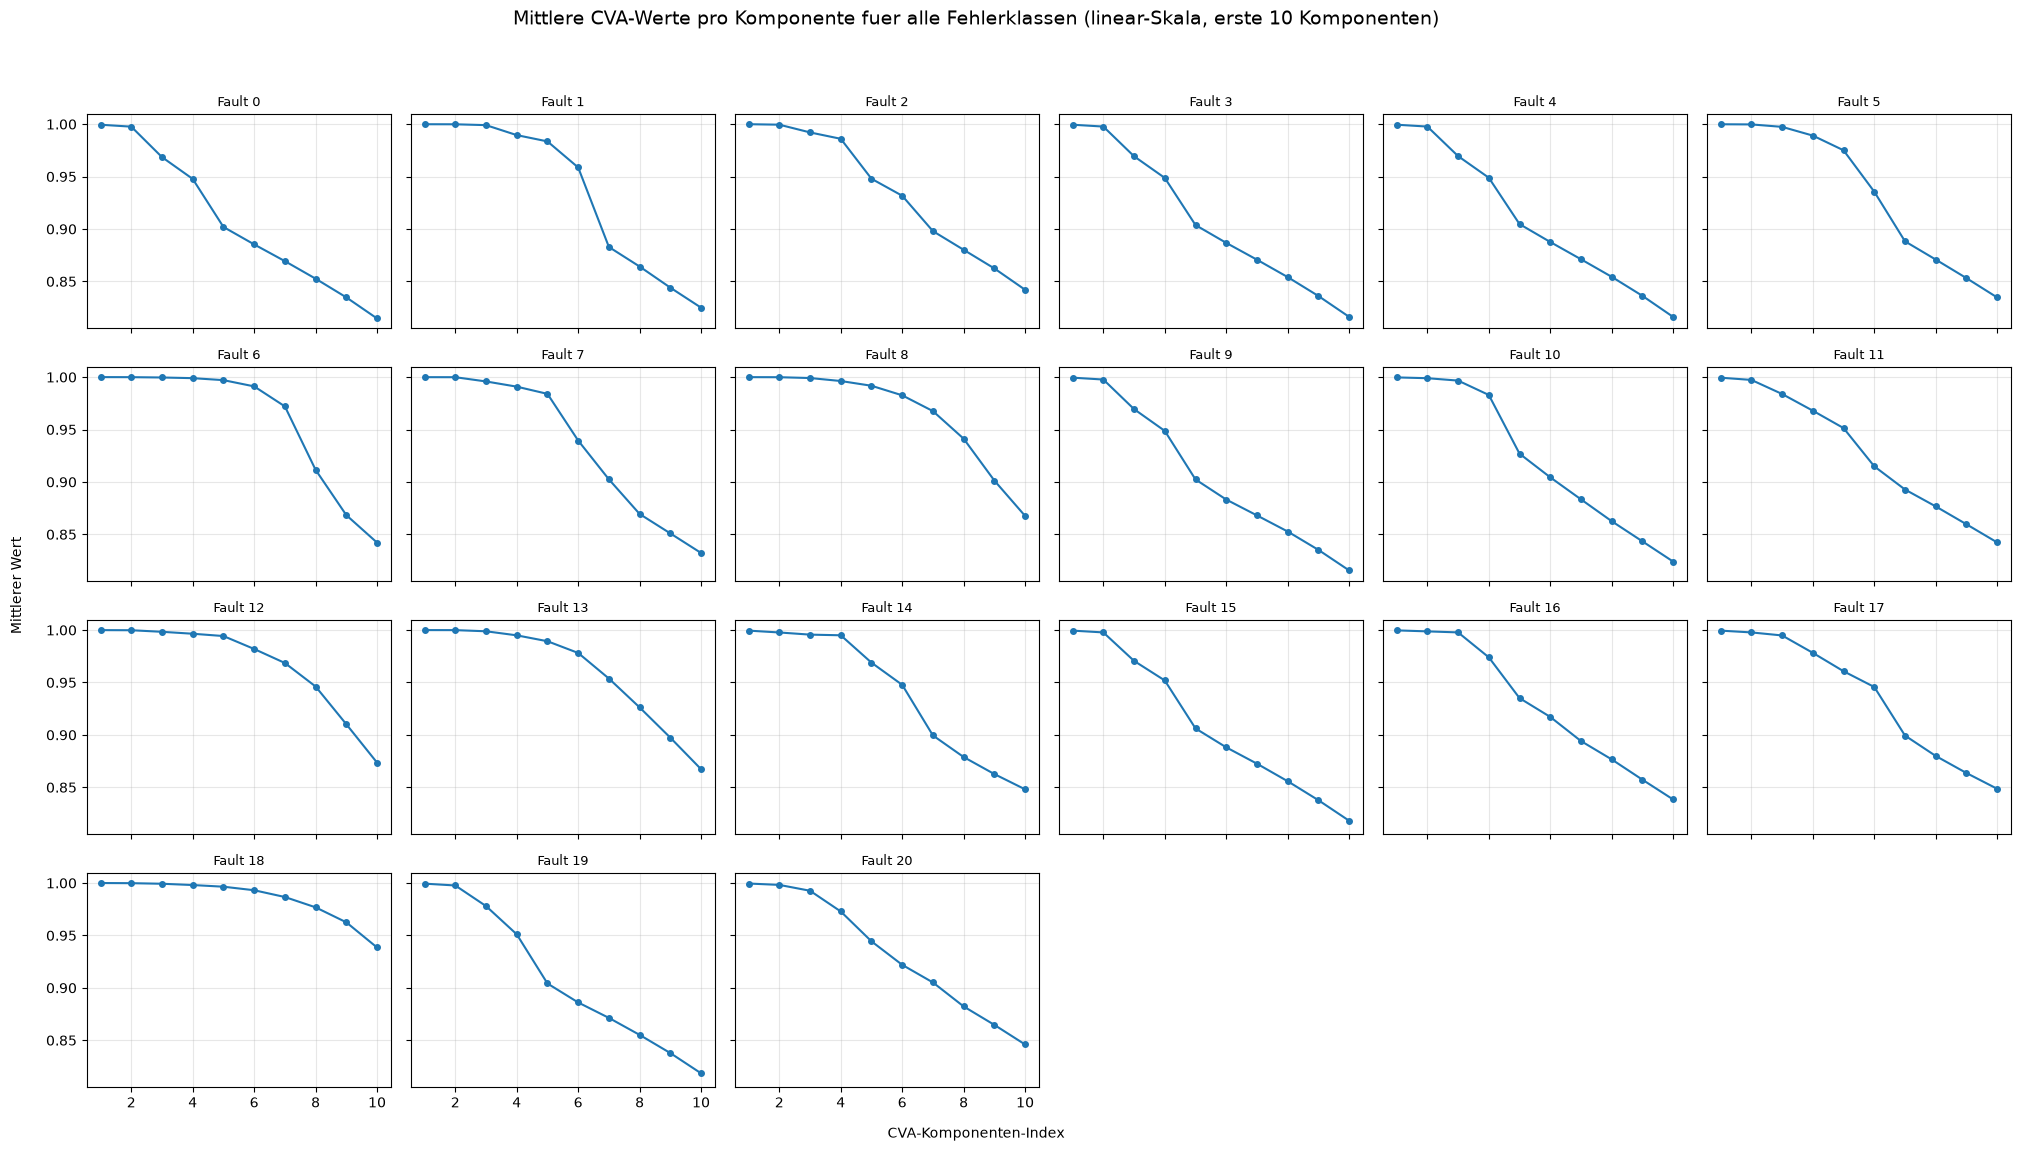

In [6]:
# ============================================================
# Mittleres Spektrum je Fehlerklasse
# ============================================================
# Ein Subplot je Fehlerklasse. Die Darstellungsart steuert
# CFG.plot_mode ("linear" | "log" | "relative"), die Zahl der
# gezeigten Komponenten CFG.k_max.
_ = plot_means(CFG, agg)

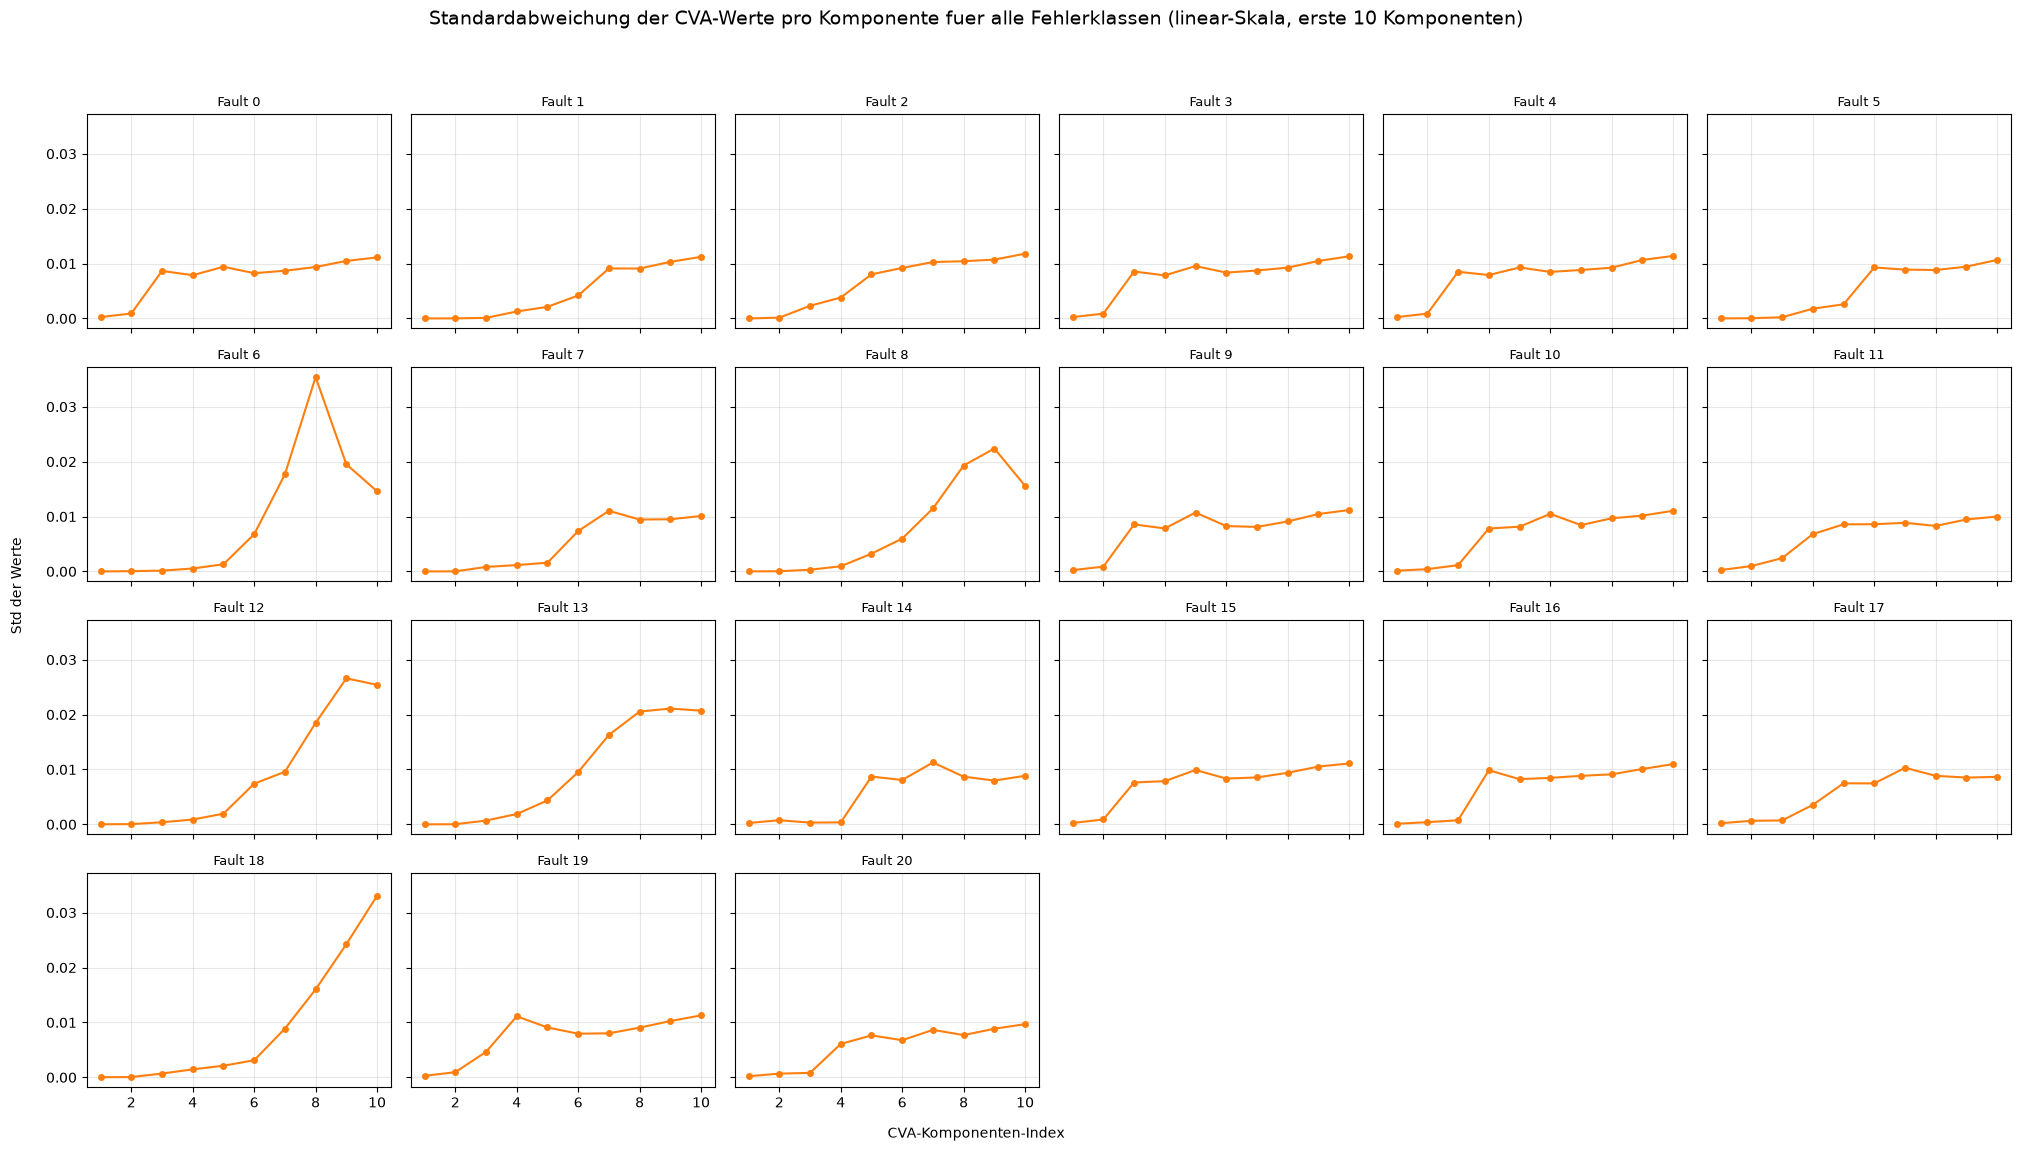

In [7]:
# ============================================================
# Standardabweichung je Komponente
# ============================================================
# Struktur identisch zum Mittelwertsplot. Eine breite Streuung heisst,
# dass die Komponente ueber die Runs einer Klasse nicht stabil ist.
_ = plot_stds(CFG, agg)

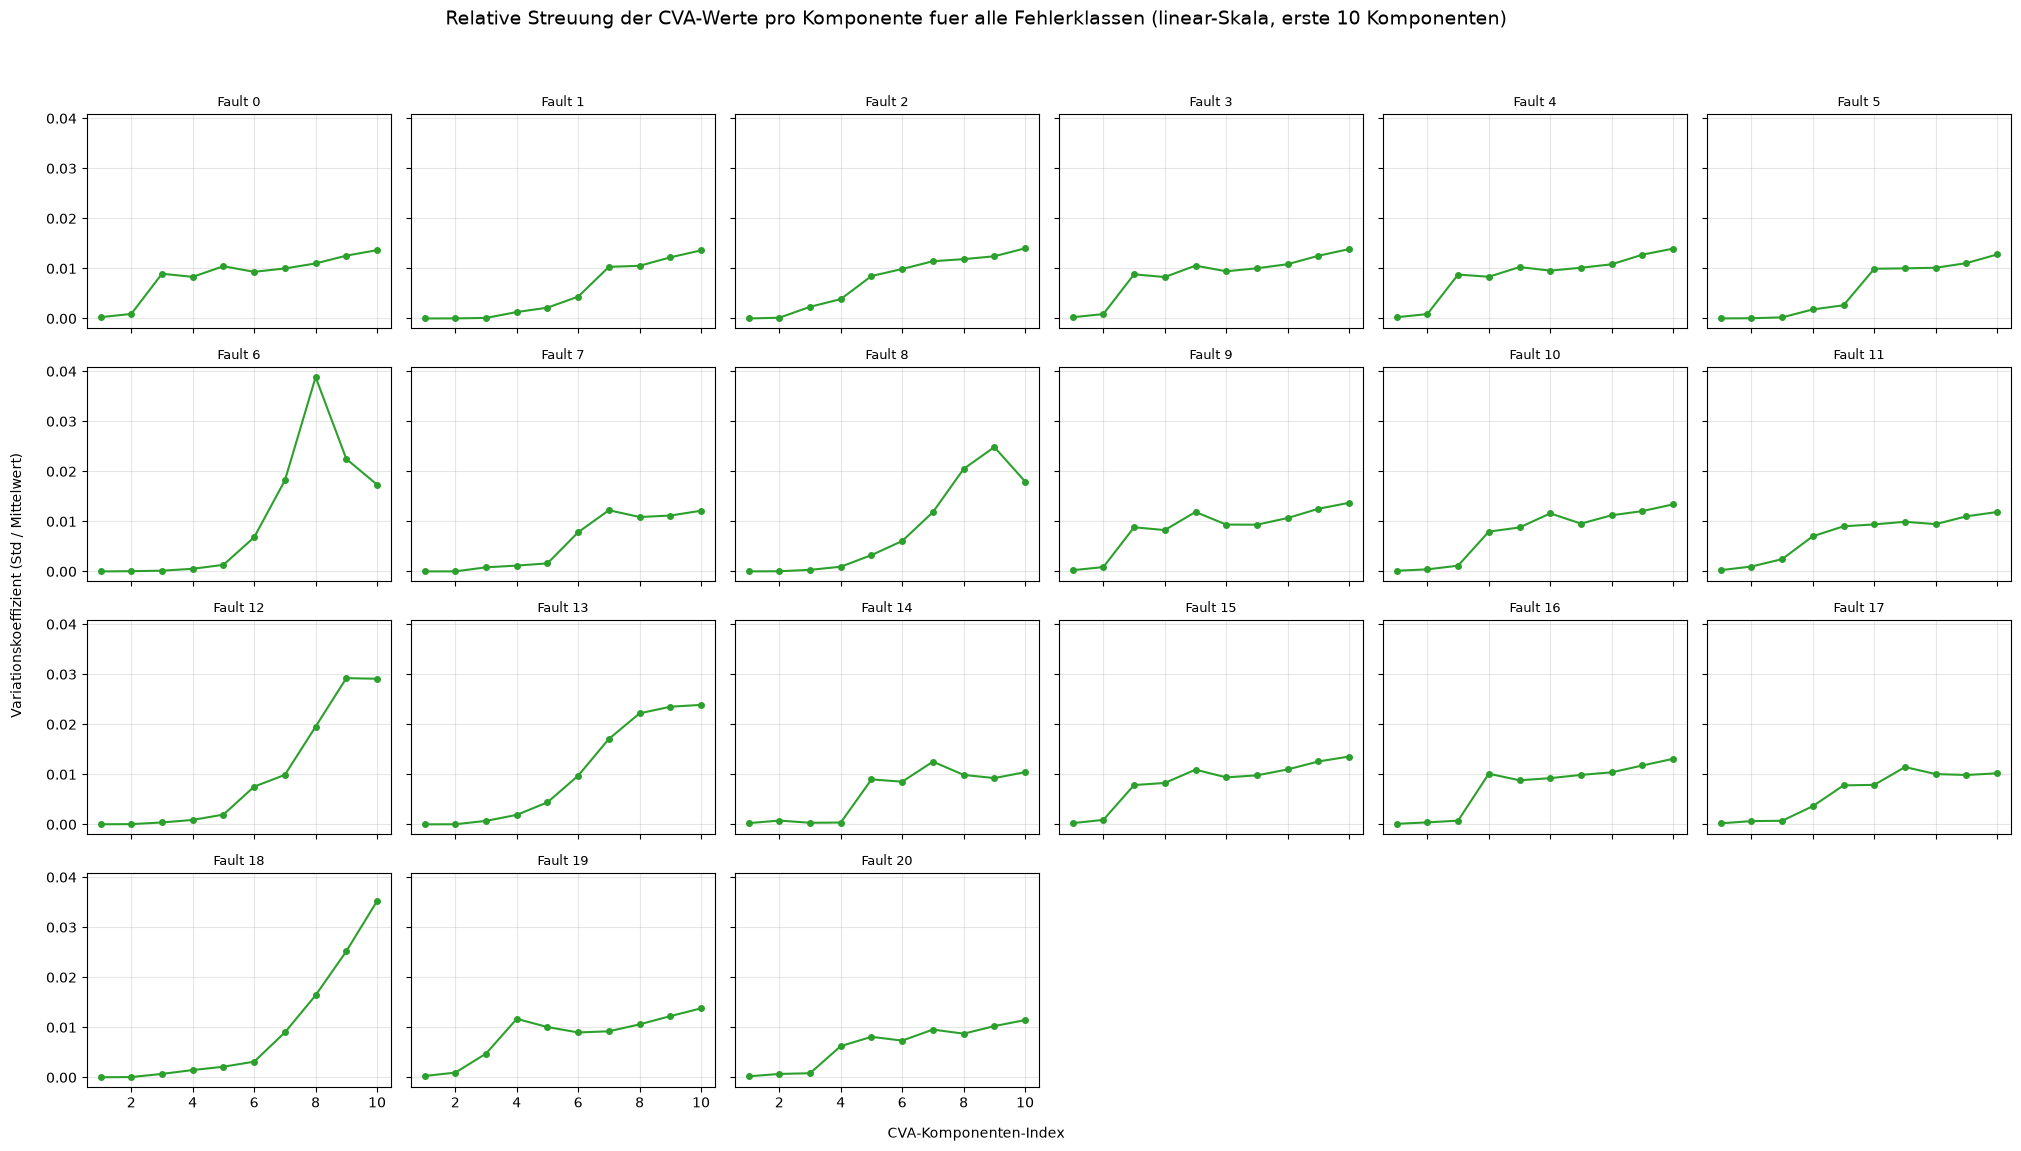

In [8]:
# ============================================================
# Relative Streuung: Variationskoeffizient CV = Std / Mittelwert
# ============================================================
# Dimensionslos und damit ueber Komponenten hinweg vergleichbar, deren
# Absolutniveau um Groessenordnungen auseinanderliegt. Eigener
# Darstellungsmodus: CFG.plot_mode_cv.
_ = plot_cv(CFG, agg)

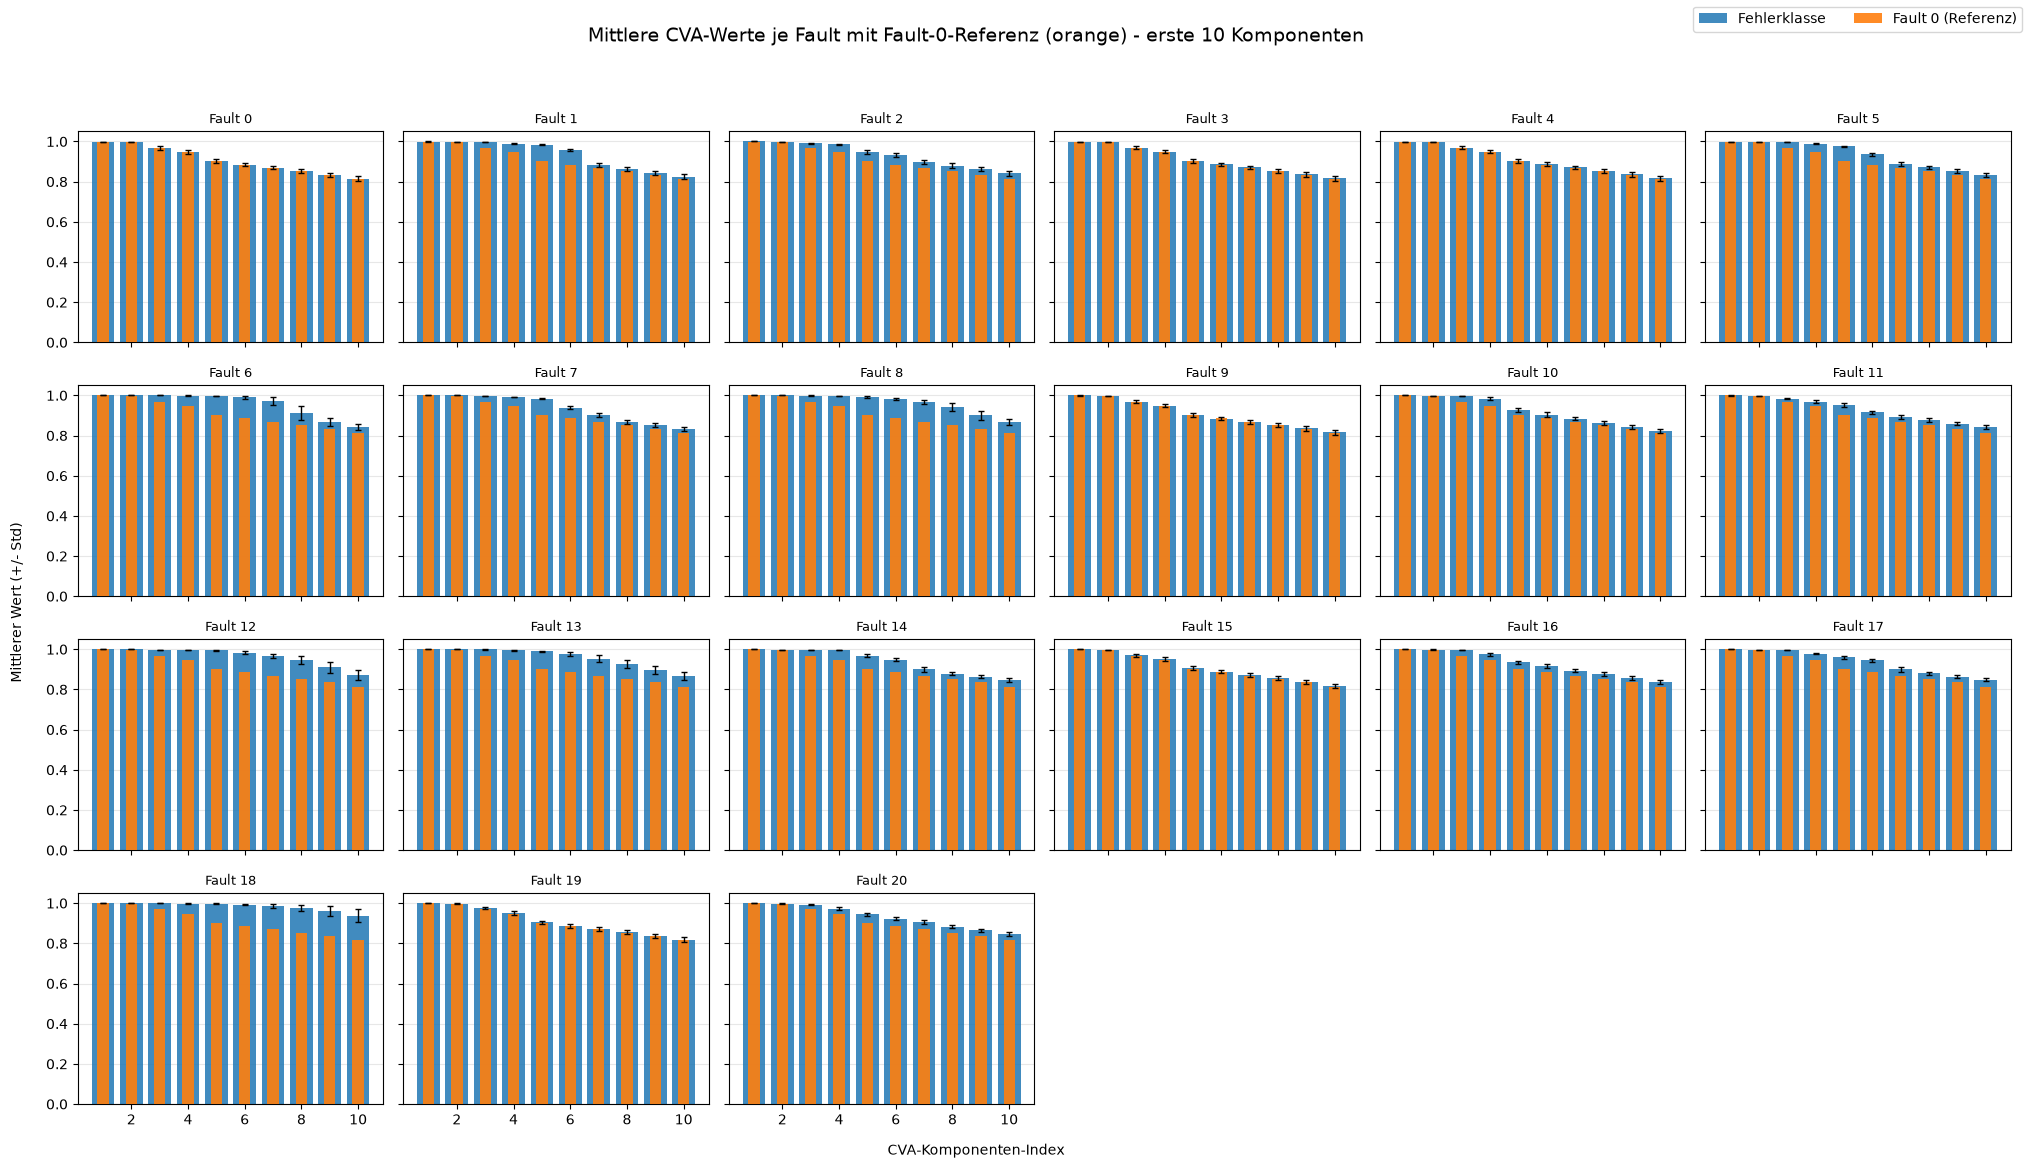

In [9]:
# ============================================================
# Erste k Werte je Fehlerklasse mit Fault-0-Referenz
# ============================================================
# Der schmale orange Balken ist Fault 0 - so ist auf einen Blick zu
# sehen, welche Komponenten sich unter dem Fehler wirklich verschieben.
# Zahl der Balken: CFG.k_bar.
_ = plot_bars(CFG, agg)

## Export der Trainings-Spektren

Schreibt `cva_eigenvalues_train.csv` neben das Notebook. `LazyClassifier_PCA_DyCA.ipynb` liest diese Datei — der Name ist deshalb eingefroren.

In [10]:
# ============================================================
# Export der Trainings-Spektren
# ============================================================
# Stellt sie fuer LazyClassifier_PCA_DyCA.ipynb bereit. Die TEST-Spektren
# werden bewusst NICHT hier berechnet, sondern dort - dieses Notebook
# bleibt training-only. Der Dateiname enthaelt den Skalierungsmodus, ein
# Umschalten ueberschreibt also nichts.
export(CFG, per_run)

CVA-Train gespeichert: (10500, 54) -> .\cva_eigenvalues_train.csv


'.\\cva_eigenvalues_train.csv'